In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob


In [ ]:

fseg = '../data/SOSE/Adelie_138E_150E/Adelie*.nc'

In [6]:
dsseg = xr.open_mfdataset(glob(fseg))

In [7]:
gyre_index = xr.open_dataarray('gyre_index.nc')
sla_ = SLA(deg=0.25).da


In [8]:
extent_ac = [138,152,-68,-63]
extent_gyre = [145,150,-66.5,-65.5]
extent_ea=[60,160,-70,-60]

region_ac = Region('AC',extent_ac)
sla = region_ac.crop_da(sla_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [12]:
# chop and resample SOSE
dsseg = dsseg.resample({'time':'MS'}).mean()

In [13]:
dsseg.load()

<xarray.Dataset> Size: 152MB
Dimensions:  (XC: 72, XG: 73, YC: 15, YG: 14, Z: 52, Zu: 52, Zl: 52, Zp1: 53,
              time: 132)
Coordinates: (12/22)
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
  * XG       (XG) float64 584B 138.0 138.2 138.3 138.5 ... 149.7 149.8 150.0
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * YG       (YG) float64 112B -65.94 -65.87 -65.8 ... -65.18 -65.11 -65.04
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu       (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
    ...       ...
    drC      (Zp1) float64 424B 2.1 4.6 5.45 6.4 7.7 ... 400.0 400.0 400.0 200.0
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC    (Z, YC, XC) float64 449kB 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    hFacW    (Z, YC, XG) float64 456kB 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    hFacS    (Z, YG, XC) float64 419kB 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
Data variables:
    ETAN     (time, YC, XC) float32 570kB -2.594 -2.581 -2.568 ... -1.639 -1.642
    SIarea   (time, YC, XC) float32 570kB 0.9754 0.9739 0.9719 ... 0.5276 0.5225
    SIheff   (time, YC, XC) float32 570kB 1.039 1.024 1.01 ... 0.2141 0.2079
    SIuice   (time, YC, XG) float32 578kB -0.284 -0.2833 ... 0.2155 0.1625
    SIvice   (time, YG, XC) float32 532kB 0.04439 0.04574 ... 0.1308 0.09934
    SIhsnow  (time, YC, XC) float32 570kB 0.2433 0.2428 ... 0.07917 0.0767
    BLGMLD   (time, YC, XC) float32 570kB 33.59 39.2 40.17 ... 37.29 29.48 26.28
    THETA    (time, Z, YC, XC) float32 30MB -1.841 -1.837 -1.832 ... 0.0 0.0 0.0
    SALT     (time, Z, YC, XC) float32 30MB 33.81 33.8 33.79 ... 0.0 0.0 0.0
    UVEL     (time, Z, YC, XG) float32 30MB -0.1135 -0.1136 -0.113 ... 0.0 0.0
    VVEL     (time, Z, YG, XC) float32 28MB -0.01574 -0.01788 ... 0.0 0.0
    WVEL     (time, Zl, YC, XC) float32 30MB -5.79e-08 -5.579e-08 ... 0.0 0.0

In [15]:
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (dsseg.SIheff * rho_ice) + (dsseg.SIhsnow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
sea_level = (dsseg.ETAN + sload)


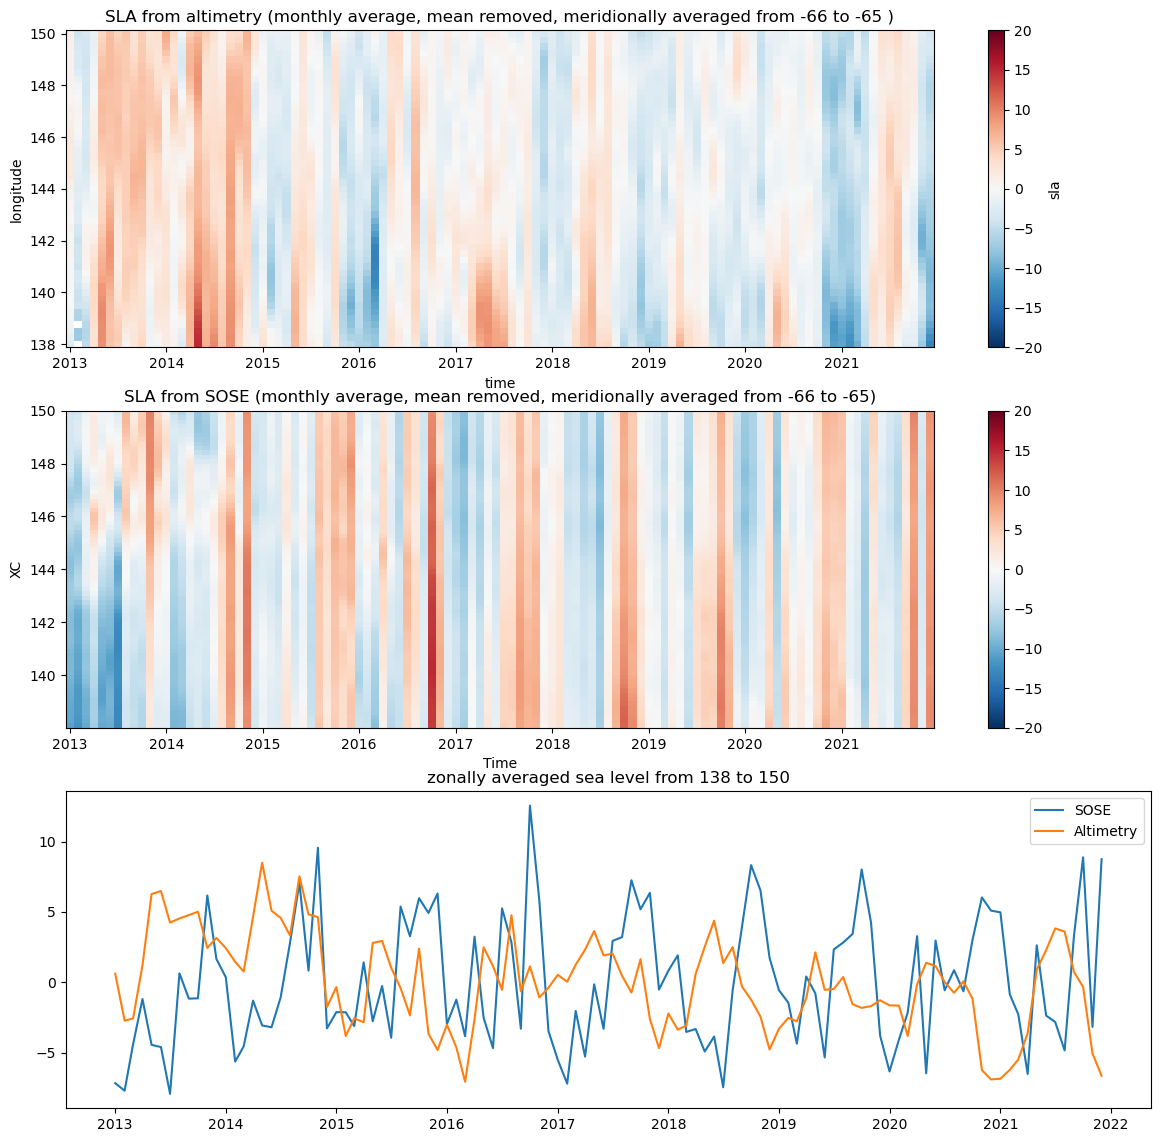

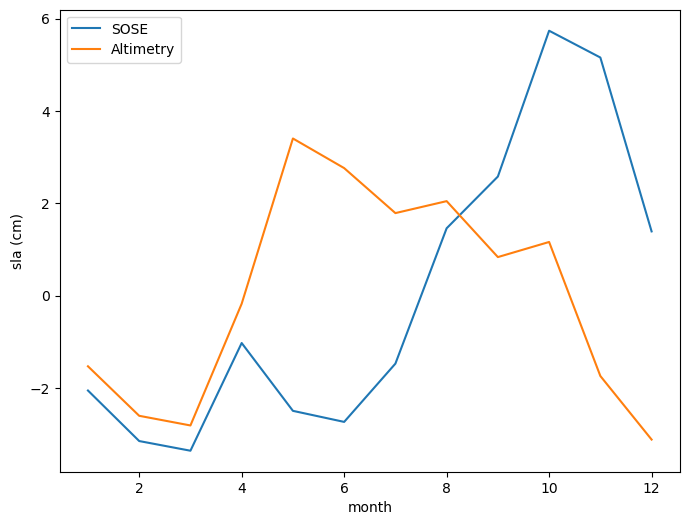

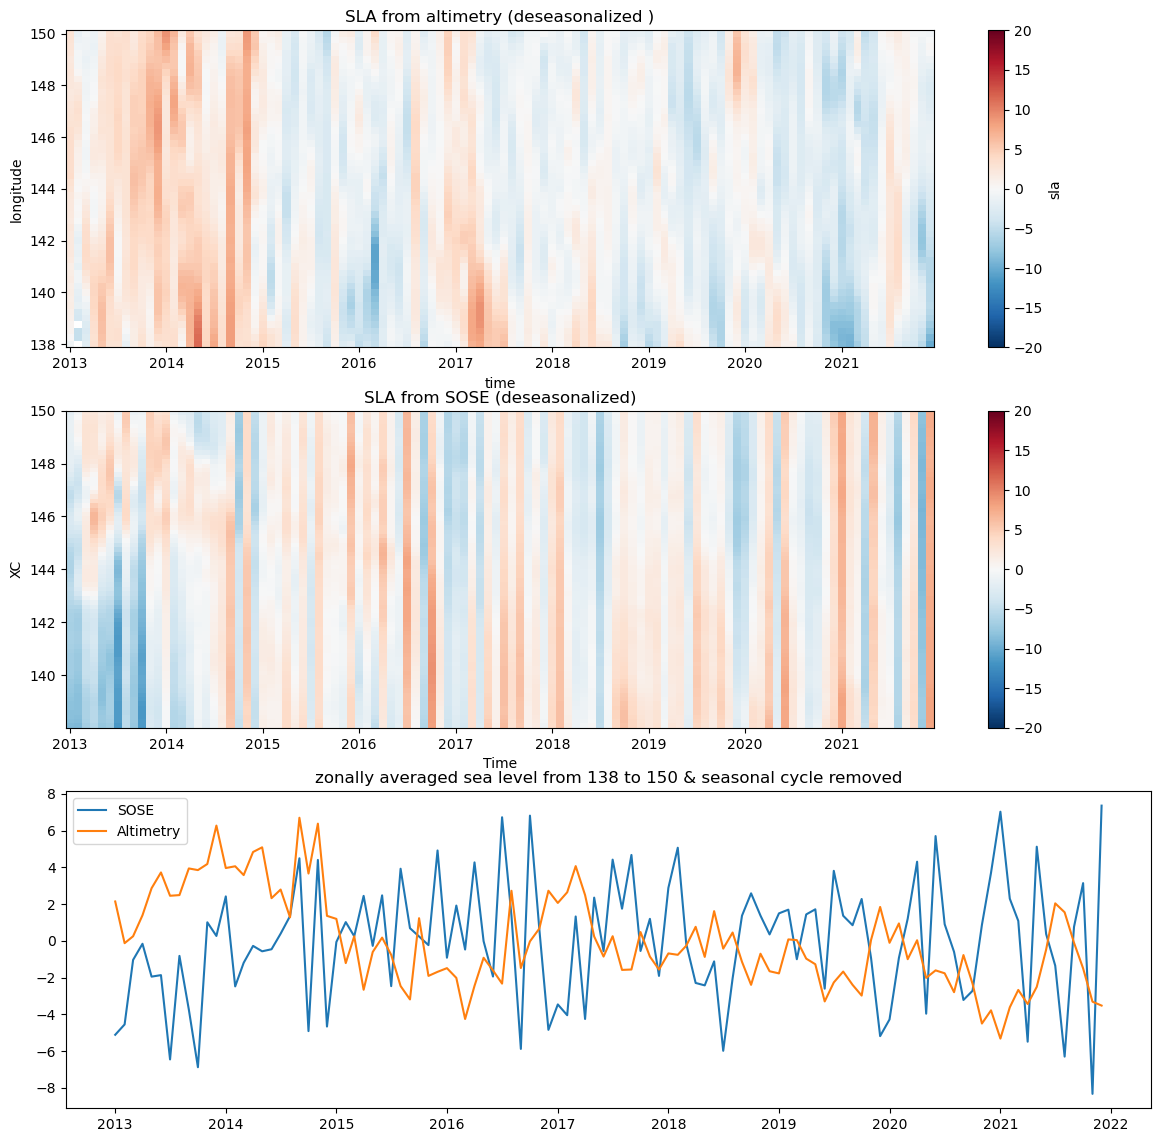

In [ ]:
sla145 = sla.sel(latitude=slice(dsseg.YC[0],dsseg.YC[-1])).mean('latitude').sel(time=slice(dsseg.time[0],sla.time[-1])).sel(longitude=slice(dsseg.XC[0],dsseg.XC[-1]))
etaSOS = sea_level.mean('YC').sel(time=slice(dsseg.time[0],sla.time[-1]))

fig,axs = plt.subplots(3,1,figsize=(14,14))

slam = sla145 - sla145.mean('time')
etam = (etaSOS - etaSOS.mean('time')) * 100

ax=axs[0]
slam.plot(x='time',y='longitude',ax=ax,vmin=-20)
ax.set_title('SLA from altimetry (monthly average, mean removed, meridionally averaged from -66 to -65 )')
#ax.set_ylim([-66.5,-65])

ax=axs[1]
etam.plot(x='time',y='XC',ax=ax,vmin=-20)
ax.set_title('SLA from SOSE (monthly average, mean removed, meridionally averaged from -66 to -65)')
#ax.set_ylim([-66.5,-65])

ax=axs[2]
ax.plot(etam.time,etam.mean('XC'),label = 'SOSE')
ax.plot(slam.time,slam.mean('longitude'), label = 'Altimetry')
ax.set_title('zonally averaged sea level from 138 to 150')
ax.legend()

fig,ax = plt.subplots(figsize=(8,6))
soseclim=etam.mean('XC').groupby('time.month').mean()
alticlim=slam.mean('longitude').groupby('time.month').mean()

ax.plot(soseclim.month,soseclim,label='SOSE')
ax.plot(alticlim.month,alticlim,label='Altimetry')
ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('sla (cm)')

fig,axs = plt.subplots(3,1,figsize=(14,14))

slama = slam.groupby('time.month') - alticlim
etama = etam.groupby('time.month') - soseclim


ax=axs[0]
slama.plot(x='time',y='longitude',ax=ax,vmin=-20)
ax.set_title('SLA from altimetry (deseasonalized )')
#ax.set_ylim([-66.5,-65])

ax=axs[1]
etama.plot(x='time',y='XC',ax=ax,vmin=-20)
ax.set_title('SLA from SOSE (deseasonalized)')
#ax.set_ylim([-66.5,-65])

ax=axs[2]
ax.plot(etama.time,etama.mean('XC'),label = 'SOSE')
ax.plot(slama.time,slama.mean('longitude'), label = 'Altimetry')
ax.set_title('zonally averaged sea level from 138 to 150 & seasonal cycle removed')
ax.legend()
